<a href="https://colab.research.google.com/github/emmanguyen01-spec/Coding-Exercise---ML-Basics/blob/main/ML/customer_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python
['Mall_Customers.csv']
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset shape:
(200, 5)

Column names:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  1

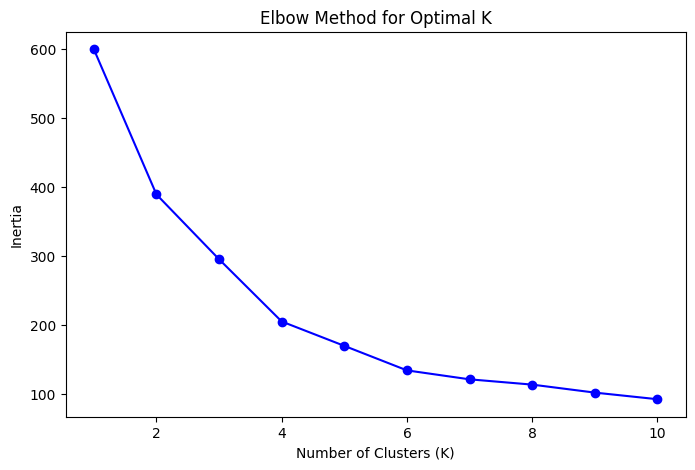


Cluster Characteristics:
           Age  Annual Income (k$)  Spending Score (1-100)
cluster                                                   
0        53.98               47.71                   39.97
1        32.88               86.10                   81.53
2        25.44               40.00                   60.30
3        39.37               86.50                   19.58

Customer segments saved to customer_segments.csv


In [2]:
import pandas as pd
import numpy as np
import os
import kagglehub

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Data Source:
# Kaggle - Customer Segmentation Tutorial in Python
# https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

# Download latest version
path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python"
)

print("Path to dataset files:", path)

# See which files are inside the dataset
print(os.listdir(path))

# Load the dataset
df = pd.read_csv(
    os.path.join(path, "Mall_Customers.csv")
)

# Preview dataset
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

# Load the dataset
df = pd.read_csv(
    os.path.join(path, "Mall_Customers.csv")
)

# Preview dataset
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

# Preprocess data: Select numerical features and scale them
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal number of clusters using elbow method
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.savefig('elbow_plot.png')
plt.show()

plt.show()

# Apply K-Means with optimal K
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42
)

df['cluster'] = kmeans.fit_predict(X_scaled)

# Analyze clusters
cluster_summary = df.groupby('cluster')[features].mean().round(2)

print("\nCluster Characteristics:")
print(cluster_summary)

# Example of targeted strategies
for cluster in range(optimal_k):
    print(f"\nCluster {cluster} Strategy:")

    if cluster == 0:
        print("Offer personalized discounts or loyalty incentives to encourage more spending.")

    elif cluster == 1:
        print("Offer exclusive promotions, premium products, and VIP loyalty rewards.")

    elif cluster == 2:
        print("Use affordable promotions, student or young-adult discounts, and social media campaigns.")

    elif cluster == 3:
        print("Use personalized recommendations and special offers to encourage higher spending.")

# Save cluster assignments to CSV
df.to_csv('customer_segments.csv', index=False)

print("\nCustomer segments saved to customer_segments.csv")

